# 🧠 Dilithium 부채널 공격: 모델 학습 및 평가 (v4 Final)

이 노트북은 가이드라인의 모든 핵심 전략을 통합하여 최상의 신호를 학습합니다.

## 📋 주요 구성
1. **데이터 준비**: 32비트 HW 기준(33-class) 및 희소 클래스 필터링
2. **모델 설계**: Inception-ResNet 아키텍처 (다중 커널 + 잔차 연결)
3. **최적화**: Focal Loss + Class Weights + Data Augmentation(Noise)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, BatchNormalization, MaxPooling1D, GlobalAveragePooling1D, Dropout, Reshape, Activation, Add, Concatenate, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

print("✅ 라이브러리 로드 완료")

# 1. 데이터 로드
X = np.load('X_train_poi400.npy')
y = np.load('y_train_hw.npy')

print(f"📊 로드된 데이터: X {X.shape}, y {y.shape}")
print(f"🔹 HW 범위: {y.min()} ~ {y.max()}")

# 2. 희소 클래스 필터링 (Stratify 오류 방지)
unique, counts = np.unique(y, return_counts=True)
rare_classes = unique[counts < 2]
if len(rare_classes) > 0:
    print(f"⚠️ 희소 클래스 제거: {rare_classes}")
    mask = ~np.isin(y, rare_classes)
    X = X[mask]
    y = y[mask]

# 3. 라벨 변환 (33개 클래스)
num_classes = 33 
y_cat = tf.keras.utils.to_categorical(y, num_classes=num_classes)

# 4. Train/Validation 분리
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.1, stratify=y, random_state=42)
print(f"✅ 데이터 분리 완료: Train {X_train.shape}, Val {X_val.shape}")

✅ 라이브러리 로드 완료
📊 로드된 데이터: X (40000, 60), y (40000,)
🔹 HW 범위: 2 ~ 30
⚠️ 희소 클래스 제거: [ 2 30]
✅ 데이터 분리 완료: Train (35998, 60), Val (4000, 60)


In [3]:
def inception_resnet_block(x, filters, reg=1e-4):
    shortcut = x
    # Branch 1: 3-kernel
    b1 = Conv1D(filters // 4, kernel_size=3, padding='same', kernel_regularizer=l2(reg))(x)
    b1 = BatchNormalization()(b1)
    b1 = Activation('relu')(b1)
    # Branch 2: 7-kernel
    b2 = Conv1D(filters // 4, kernel_size=7, padding='same', kernel_regularizer=l2(reg))(x)
    b2 = BatchNormalization()(b2)
    b2 = Activation('relu')(b2)
    # Branch 3: 11-kernel
    b3 = Conv1D(filters // 2, kernel_size=11, padding='same', kernel_regularizer=l2(reg))(x)
    b3 = BatchNormalization()(b3)
    b3 = Activation('relu')(b3)
    
    merged = Concatenate()([b1, b2, b3])
    
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding='same', kernel_regularizer=l2(reg))(shortcut)
        shortcut = BatchNormalization()(shortcut)
        
    x = Add()([merged, shortcut])
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    return x

def build_final_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Reshape(input_shape + (1,))(inputs)
    x = GaussianNoise(0.05)(x)
    
    # Stem
    x = Conv1D(64, kernel_size=11, padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # Inception-ResNet Layers
    x = inception_resnet_block(x, 64)
    x = inception_resnet_block(x, 128)
    x = inception_resnet_block(x, 256)
    
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.6)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)

model = build_final_model((X_train.shape[1],), num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
    metrics=['accuracy']
)

# 가중치 계산
y_ints = np.argmax(y_train, axis=1)
weights = compute_class_weight('balanced', classes=np.unique(y_ints), y=y_ints)
weight_dict = dict(zip(np.unique(y_ints), weights))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
    ModelCheckpoint('dilithium_final_v4.keras', save_best_only=True)
]

print("🚀 학습 시작...")
history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), 
    epochs=100, 
    batch_size=128, 
    class_weight=weight_dict, 
    callbacks=callbacks, 
    verbose=1
)

🚀 학습 시작...
Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.0584 - loss: 0.9971 - val_accuracy: 0.0900 - val_loss: 0.7201 - learning_rate: 0.0010
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.1125 - loss: 0.7116 - val_accuracy: 0.1233 - val_loss: 0.6017 - learning_rate: 0.0010
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.1253 - loss: 0.6370 - val_accuracy: 0.1110 - val_loss: 0.8560 - learning_rate: 0.0010
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.1415 - loss: 0.6033 - val_accuracy: 0.0812 - val_loss: 0.7183 - learning_rate: 0.0010
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2000 - loss: 0.5036 - val_accuracy: 0.0948 - val_loss: 0.7728 - learning_rate: 0.0010
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.1687 - loss: 0.5552 - val_accuracy: 0.2715 - val_loss: 0.4334 - learning_rate: 2.0000e-04
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accu

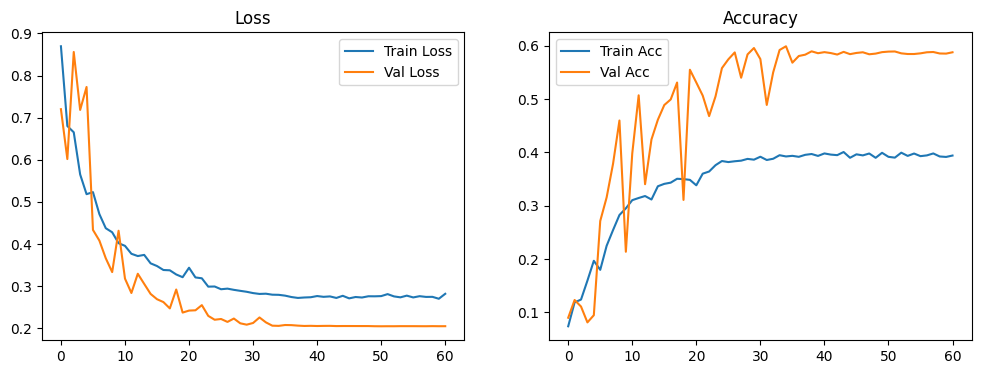

In [4]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()